In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir('/content/drive/MyDrive/UNSW_Blanced')

In [ ]:
!pip install adversarial-robustness-toolbox


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 63.8 MB/s eta 0:00:00


In [ ]:
#@title Env & setup
!pip -q install numpy pandas scikit-learn scipy

import os, time, random, math, json
import numpy as np
import pandas as pd
from math import ceil
from typing import Dict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score

from scipy.stats import norm
from scipy.stats import beta as beta_dist


def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cuda')

In [ ]:
#@title Load URL dataset → tensors
import pandas as pd
import numpy as np
import torch

train = pd.read_csv('url_balanced_train_data.csv')
test  = pd.read_csv('url_balanced_test_data.csv')

X_train = train.drop(columns=['label']).values
y_train = train['label'].values
X_test  = test.drop(columns=['label']).values
y_test  = test['label'].values

X_train_tensor = torch.tensor(np.array(X_train), dtype=torch.float32)
y_train_tensor = torch.tensor(np.array(y_train), dtype=torch.long)
X_test_tensor  = torch.tensor(np.array(X_test),  dtype=torch.float32)
y_test_tensor  = torch.tensor(np.array(y_test),  dtype=torch.long)

print("Train:", X_train_tensor.shape, y_train_tensor.shape)
print("Test :", X_test_tensor.shape,  y_test_tensor.shape)


Train: torch.Size([9086, 63]) torch.Size([9086])
Test : torch.Size([2272, 63]) torch.Size([2272])


In [ ]:
#@title Base model
import torch.nn as nn

class TabularNN(nn.Module):
    def __init__(self, input_size, dropout_rate=0.25):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 2)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = torch.relu(self.fc1(x)); x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        return self.fc4(x)


In [ ]:
#@title Train base model (clean)
input_size = X_train_tensor.shape[1]
model = TabularNN(input_size=input_size).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_tensor,  y_test_tensor),  batch_size=256, shuffle=False)

results_file = "results_baseline/url_evaluation_results.txt"
os.makedirs(os.path.dirname(results_file), exist_ok=True)
with open(results_file, "w") as f:
    f.write("Model Evaluation Results\n" + "="*50 + "\n")

epochs = 10
for epoch in range(epochs):
    model.train()
    run = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward(); optimizer.step()
        run += float(loss.item())
    ep_loss = run / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {ep_loss:.4f}")
    with open(results_file, "a") as f:
        f.write(f"Epoch [{epoch+1}/{epochs}] Loss: {ep_loss:.4f}\n")

# Clean test accuracy
model.eval()
with torch.no_grad():
    logits = model(X_test_tensor.to(device))
    pred = torch.argmax(logits, dim=1).cpu()
clean_acc = accuracy_score(y_test_tensor.numpy(), pred.numpy())
print(f"Clean test accuracy: {clean_acc:.4f}")
with open(results_file, "a") as f:
    f.write(f"\nClean test accuracy: {clean_acc:.4f}\n")


Epoch [1/10] Loss: 0.3545
Epoch [2/10] Loss: 0.1955
Epoch [3/10] Loss: 0.1733
Epoch [4/10] Loss: 0.1606
Epoch [5/10] Loss: 0.1489
Epoch [6/10] Loss: 0.1425
Epoch [7/10] Loss: 0.1344
Epoch [8/10] Loss: 0.1300
Epoch [9/10] Loss: 0.1246
Epoch [10/10] Loss: 0.1238
Clean test accuracy: 0.9507


In [ ]:
#@title Evaluate base model on adversarial matrices
def robust_load_matrix(path: str) -> np.ndarray:
    try:
        return np.loadtxt(path, delimiter=",", dtype=np.float32)
    except Exception:
        return np.loadtxt(path, dtype=np.float32)

adversarial_loaders_pre = {
    "PGD": "X_adv_pgd_url_norm2.txt",
    "FGSM": "X_adv_fgsm_url_norm2.txt",
    "JSMA": "X_adv_jsma_url.txt",
    "DeepFool": "X_adv_df_url.txt",
    "ZOO": "X_adv_zoo_agg_url3.txt",
    "CW": "X_adv_cw_agg_url2.txt",
    "LPF": "X_adv_lpf_url.csv",
    "HSJ": "X_adv_hsj_url.txt",
}

for attack_name, file_path in adversarial_loaders_pre.items():
    X_adv = robust_load_matrix(file_path)

    if X_adv.shape[1] != X_train_tensor.shape[1]:
        print(f"[SKIP] {attack_name}: {X_adv.shape[1]} features != {X_train_tensor.shape[1]}")
        continue

    X_adv_tensor = torch.tensor(X_adv, dtype=torch.float32).to(device)
    t0 = time.time()
    with torch.no_grad():
        adv_pred = model(X_adv_tensor).argmax(1).cpu().numpy()
    dt = time.time() - t0

    adv_acc = accuracy_score(y_test_tensor.numpy(), adv_pred)
    print(f"{attack_name} adversarial accuracy: {adv_acc:.4f} | time {dt:.2f}s")
    with open(results_file, "a") as f:
        f.write(f"{attack_name} adversarial accuracy: {adv_acc:.4f}\n")
        f.write(f"Time taken for {attack_name}: {dt:.2f}s\n")


PGD adversarial accuracy: 0.4252 | time 0.00s
FGSM adversarial accuracy: 0.5889 | time 0.00s
JSMA adversarial accuracy: 0.2161 | time 0.00s
DeepFool adversarial accuracy: 0.4419 | time 0.00s
ZOO adversarial accuracy: 0.9441 | time 0.00s
CW adversarial accuracy: 0.5106 | time 0.00s
LPF adversarial accuracy: 0.2610 | time 0.00s
HSJ adversarial accuracy: 0.7201 | time 0.00s


In [ ]:
###########ADAPTIVE MODEL##############



import os
import time
import numpy as np
from math import ceil
from scipy.stats import norm, beta as beta_dist

class AdaptiveSmoothEntropy:
    ABSTAIN = -1

    def __init__(self, base_classifier, num_classes, initial_sigma=1.0):
        self.base_classifier = base_classifier.to(device)
        self.num_classes = int(num_classes)
        self.sigma = float(initial_sigma)

    # ----------------------- TRAINING -----------------------
    def train_model(
        self,
        train_loader,
        test_loader,
        num_epochs=15,
        switch_epoch=None,
        ramp_epochs=5,
        lr_init=1e-3,
        lr_drop=0.5,
        beta_noisy0=0.5,
        beta_noisy1=1.0,
        lambda_consistency_base=0.1,
        noise_floor=0.20
    ):
        optimizer = optim.AdamW(self.base_classifier.parameters(), lr=lr_init, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

        if switch_epoch is None:
            switch_epoch = num_epochs // 2

        def _freeze_bn_running(m):
            if isinstance(m, nn.BatchNorm1d):
                m.eval()

        for epoch in range(num_epochs):
            self.base_classifier.train()

            if epoch < switch_epoch:
                ramp = 0.0
            else:
                if epoch == switch_epoch:
                    self.base_classifier.apply(_freeze_bn_running)
                    for g in optimizer.param_groups:
                        g['lr'] *= lr_drop
                ramp = min(1.0, (epoch - switch_epoch + 1) / max(1, ramp_epochs))

            running_loss = 0.0

            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                outputs_clean = self.base_classifier(inputs)
                loss_clean = nn.CrossEntropyLoss()(outputs_clean, labels)

                if ramp > 0.0:
                    with torch.no_grad():
                        probs = torch.softmax(outputs_clean, dim=1)
                        ent = -torch.sum(probs * torch.log(probs + 1e-8), dim=1)

                    scale = 1.0 - (ent / np.log(self.num_classes))
                    scale = noise_floor + (1.0 - noise_floor) * scale
                    scale = scale * ramp

                    noise = torch.randn_like(inputs) * self.sigma * scale.unsqueeze(1)
                    noisy_inputs = inputs + noise

                    outputs_noisy = self.base_classifier(noisy_inputs)
                    loss_noisy = nn.CrossEntropyLoss()(outputs_noisy, labels)

                    with torch.no_grad():
                        p_clean = torch.softmax(outputs_clean, dim=1)
                    logp_noisy = torch.log_softmax(outputs_noisy, dim=1)
                    consistency = torch.sum(
                        p_clean * (torch.log(p_clean + 1e-8) - logp_noisy), dim=1
                    ).mean()

                    loss = (
                        loss_clean
                        + (beta_noisy0 + (beta_noisy1 - beta_noisy0) * ramp) * loss_noisy
                        + (lambda_consistency_base * ramp) * consistency
                    )
                else:
                    loss = loss_clean

                loss.backward()
                optimizer.step()
                running_loss += loss.item()

            scheduler.step()
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}, ramp={ramp:.2f}")
            self.evaluate(test_loader)

    def mix_clean_and_noisy(self, inputs, ramp=1.0, noise_floor=0.20):
        clean_inputs = inputs.clone()
        with torch.no_grad():
            probs = torch.softmax(self.base_classifier(clean_inputs), dim=1)
            entropies = -torch.sum(probs * torch.log(probs + 1e-8), dim=1)
        scale = 1.0 - (entropies / np.log(self.num_classes))
        scale = noise_floor + (1.0 - noise_floor) * scale
        scale = scale * ramp
        noise = torch.randn_like(inputs) * self.sigma * scale.unsqueeze(1)
        noisy_inputs = inputs + noise
        return clean_inputs, noisy_inputs

    def evaluate(self, loader):
        self.base_classifier.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = self.base_classifier(inputs)
                predicted = torch.argmax(outputs, dim=1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        acc = 100.0 * correct / total if total > 0 else 0.0
        print(f"Accuracy on clean data: {acc:.2f}%")
        return acc

    @staticmethod
    def _cp_lower(k: int, n: int, alpha: float) -> float:
        if n == 0 or k <= 0:
            return 0.0
        return float(beta_dist.ppf(alpha, k, n - k + 1))

    @staticmethod
    def _cp_upper(k: int, n: int, alpha: float) -> float:
        if n == 0 or k >= n:
            return 1.0
        return float(beta_dist.ppf(1.0 - alpha, k + 1, n - k))

    @staticmethod
    def _ppf_safe(p: float) -> float:
        p = float(np.clip(p, 1e-12, 1 - 1e-12))
        return float(norm.ppf(p))

    def _proxy_margin(self, x):
        with torch.no_grad():
            probs = torch.softmax(self.base_classifier(x), dim=1).squeeze()
        top2 = torch.topk(probs, 2).values
        return (top2[0] - top2[1]).item(), top2[0].item()

    def _adaptive_sample_size(self, margin, confidence, n_base, max_scale=3.0, gamma=2.0):
        scale = max(1.0, (1.0 - margin) * (1.0 - confidence) * gamma)
        scale = min(scale, max_scale)
        return int(ceil(n_base * scale))

    def _sample_noise(self, x, num, batch_size):
        counts = np.zeros(self.num_classes, dtype=int)
        remaining = int(num)
        with torch.no_grad():
            while remaining > 0:
                bs = min(batch_size, remaining)
                remaining -= bs
                batch = x.repeat((bs, 1)).float().to(device)
                noise = torch.randn_like(batch) * self.sigma
                predictions = self.base_classifier(batch + noise).argmax(1)
                counts += np.bincount(predictions.cpu().numpy(), minlength=self.num_classes)
        return counts

    def certify(self, x, n0=200, n_base=1000, alpha=0.001, batch_size=256):
        self.base_classifier.eval()

        counts_selection = self._sample_noise(x, n0, batch_size)
        cA_hat = int(np.argmax(counts_selection))

        margin, confidence = self._proxy_margin(x)
        n = self._adaptive_sample_size(margin, confidence, n_base=n_base)

        counts_estimation = self._sample_noise(x, n, batch_size)
        nA = int(counts_estimation[cA_hat])

        pA_LB = self._cp_lower(nA, n, alpha)

        if self.num_classes == 2:
            if pA_LB <= 0.5:
                return AdaptiveSmoothEntropy.ABSTAIN, 0.0
            R = self.sigma * self._ppf_safe(pA_LB)
            return cA_hat, max(0.0, R)

        cB_hat = int(np.argsort(counts_estimation)[-2]) if self.num_classes > 1 else cA_hat
        nB = int(counts_estimation[cB_hat])
        pB_UB = self._cp_upper(nB, n, alpha)

        if pA_LB <= 0.5 or pA_LB <= pB_UB:
            return AdaptiveSmoothEntropy.ABSTAIN, 0.0

        R = 0.5 * self.sigma * (self._ppf_safe(pA_LB) - self._ppf_safe(pB_UB))
        return cA_hat, max(0.0, R)

    def test_on_adversarial(self, X_adv_test, y_test, method="margin",
                            n0=200, n=1000, alpha=0.001, batch_size=64,
                            save_to: str = None, tag: str = ""):
        total = len(X_adv_test)
        correct = 0
        certified_correct = 0
        abstain = 0
        radii = []

        t_all_start = time.time()
        certify_time = 0.0

        with torch.no_grad():
            for i in range(total):
                x_adv_sample = torch.tensor(X_adv_test[i]).unsqueeze(0).to(device).float()
                y_true = int(y_test[i].item() if hasattr(y_test[i], 'item') else y_test[i])

                t0 = time.time()
                certified_class, certified_radius = self.certify(
                    x_adv_sample, n0=n0, n_base=n, alpha=alpha, batch_size=batch_size
                )
                certify_time += (time.time() - t0)

                outputs = self.base_classifier(x_adv_sample)
                predicted = torch.argmax(outputs, dim=1).item()

                if predicted == y_true:
                    correct += 1
                if certified_class == y_true:
                    certified_correct += 1
                if certified_class == AdaptiveSmoothEntropy.ABSTAIN:
                    abstain += 1
                if certified_radius > 0:
                    radii.append(certified_radius)

        total_time = time.time() - t_all_start
        ms_per_sample = (certify_time / max(total, 1)) * 1000.0

        accuracy = (correct / total * 100.0) if total > 0 else 0.0
        certified_accuracy = (certified_correct / total * 100.0) if total > 0 else 0.0
        abstention_rate = (abstain / total * 100.0) if total > 0 else 0.0
        avg_radius = float(np.mean(radii)) if radii else 0.0

        msg = (f"{tag} {method.capitalize()} | Acc: {accuracy:.2f}% | "
               f"Certified: {certified_accuracy:.2f}% | Abstain: {abstention_rate:.2f}% | "
               f"Avg R: {avg_radius:.4f} | TimeTot: {total_time:.2f}s | Cert ms/sample: {ms_per_sample:.2f}")
        print(msg)

        if save_to is not None:
            os.makedirs(os.path.dirname(save_to), exist_ok=True) if os.path.dirname(save_to) else None
            with open(save_to, "a") as f:
                f.write(msg + "\n")

        return accuracy, certified_accuracy, abstention_rate, avg_radius, total_time, ms_per_sample

    def set_sigma(self, new_sigma: float):
        self.sigma = float(new_sigma)


In [ ]:
###########ADAPTIVE MODEL##############
def train_and_evaluate_on_adversarial_folds(
    base_model_class,
    adaptive_model_class,
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    adversarial_loaders,
    num_classes,
    initial_sigma,
    batch_size=64,
    num_epochs=30,
    folds=5,
    output_file="results/sigma0.5_masking_less_url_adaptive_smoothing.txt",
    config=None,
):
    import os, time
    import numpy as np
    import torch
    from torch.utils.data import DataLoader, TensorDataset, Subset
    from sklearn.model_selection import KFold
    from collections import defaultdict

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if config is None:
        config = {
            "lambda": 0.10,
            "noise_floor": 0.20,
            "ramp_epochs": 5
        }

    def _ensure_results_dir(path):
        d = os.path.dirname(path)
        if d:
            os.makedirs(d, exist_ok=True)

    def _load_matrix(path: str) -> np.ndarray:
        try:
            return np.loadtxt(path, delimiter=",", dtype=np.float32)
        except Exception:
            return np.loadtxt(path, dtype=np.float32)

    preloaded_adv = {}
    for attack_name, file_path in adversarial_loaders.items():
        if attack_name.lower() == "clean":
            preloaded_adv[attack_name] = X_test_tensor.cpu().numpy().astype(np.float32)
        else:
            mat = _load_matrix(file_path)
            preloaded_adv[attack_name] = mat.astype(np.float32)

    n_test = X_test_tensor.shape[0]
    for name, mat in preloaded_adv.items():
        if mat.shape[0] < n_test:
            raise ValueError(f"[{name}] rows {mat.shape[0]} < test set size {n_test}.")

    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

    kf = KFold(n_splits=folds, shuffle=True, random_state=42)

    _ensure_results_dir(output_file)
    with open(output_file, "w") as f:
        f.write("===== Adversarial Evaluation Results =====\n")
        f.write(f"initial_sigma = {initial_sigma}\n")
        f.write(f"folds = {folds}, batch_size = {batch_size}, epochs = {num_epochs}\n")
        f.write(f"lambda = {config['lambda']}, noise_floor = {config['noise_floor']}, ramp_epochs = {config['ramp_epochs']}\n\n")

    print("Initializing models...")
    base_model = base_model_class(input_size=X_train_tensor.shape[1], dropout_rate=0.5).to(device)
    adaptive_model = adaptive_model_class(
        base_classifier=base_model,
        num_classes=num_classes,
        initial_sigma=initial_sigma,
    )

    print("Training AdaptiveSmoothEntropy model...")
    adaptive_model.train_model(
        train_loader,
        test_loader,
        num_epochs=num_epochs,
        lambda_consistency_base=config["lambda"],
        noise_floor=config["noise_floor"],
        ramp_epochs=config["ramp_epochs"]
    )

    print("Evaluating on clean testing data (full):")
    clean_accuracy = adaptive_model.evaluate(test_loader)
    print(f"Clean Test Accuracy: {clean_accuracy:.2f}%")
    with open(output_file, "a") as f:
        f.write(f"Clean Test Accuracy (full): {clean_accuracy:.2f}%\n")

    adversarial_summary = defaultdict(list)

    for fold, (_, test_idx) in enumerate(kf.split(test_dataset), start=1):
        print(f"\n===== Fold {fold}/{folds} =====")
        val_subset = Subset(test_dataset, test_idx)
        y_val = torch.stack([val_subset[i][1] for i in range(len(val_subset))]).cpu().numpy()

        with open(output_file, "a") as f:
            f.write(f"\nFold {fold} (Clean Acc full test: {clean_accuracy:.2f}%)\n")

        for attack_name, mat in preloaded_adv.items():
            print(f"\nEvaluating {attack_name} on Fold {fold}...")
            X_adv_fold = mat[np.array(test_idx)]
            X_adv_tensor = torch.tensor(X_adv_fold, dtype=torch.float32, device=device)

            acc, cert_acc, abstain_pct, avg_R, time_s, ms_ps = adaptive_model.test_on_adversarial(
                X_adv_tensor,
                y_val,
                method="margin",
                n0=200,
                n=1000,
                alpha=0.001,
                batch_size=batch_size,
                save_to=output_file,
                tag=f"[sigma={initial_sigma}] [fold={fold}] [attack={attack_name}]"
            )

            adversarial_summary[attack_name].append(
                (acc, cert_acc, abstain_pct, avg_R, time_s, ms_ps)
            )

    print("\n===== Adversarial Evaluation Summary =====")
    with open(output_file, "a") as f:
        f.write("\n===== Adversarial Evaluation Summary =====\n")
        for attack_name, metrics in adversarial_summary.items():
            arr = np.array(metrics, dtype=float)
            avg_acc   = float(np.mean(arr[:, 0]))
            avg_cert  = float(np.mean(arr[:, 1]))
            avg_abst  = float(np.mean(arr[:, 2]))
            avg_rad   = float(np.mean(arr[:, 3]))
            avg_time  = float(np.mean(arr[:, 4]))
            avg_msps  = float(np.mean(arr[:, 5]))
            line = (f"{attack_name}: Avg Acc={avg_acc:.2f}%, "
                    f"Avg Certified={avg_cert:.2f}%, "
                    f"Avg Abstain={avg_abst:.2f}%, "
                    f"Avg R={avg_rad:.4f}, "
                    f"Avg Time={avg_time:.2f}s, "
                    f"Avg Cert ms/sample={avg_msps:.2f}")
            print(line)
            f.write(line + "\n")

    return adversarial_summary, clean_accuracy

In [ ]:
import pandas as pd

def run_sensitivity_analysis(
    base_model_class,
    adaptive_model_class,
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    adversarial_loaders,
    num_classes,
    initial_sigma,
    batch_size=64,
    num_epochs=30,
    folds=5,
    results_dir="results_sensitivity_analysis"
):
    os.makedirs(results_dir, exist_ok=True)

    lambda_vals = [0.05, 0.10, 0.20]
    noise_floor_vals = [0.10, 0.20, 0.30]
    ramp_vals = [3, 5, 7]

    rows = []

    for lam in lambda_vals:
        for nf in noise_floor_vals:
            for ramp in ramp_vals:
                config = {
                    "lambda": lam,
                    "noise_floor": nf,
                    "ramp_epochs": ramp
                }

                print("\n==============================")
                print(f"Running config: {config}")
                print("==============================")

                output_file = os.path.join(
                    results_dir,
                    f"sens_l{lam}_nf{nf}_r{ramp}.txt"
                )

                results, clean_acc = train_and_evaluate_on_adversarial_folds(
                    base_model_class=base_model_class,
                    adaptive_model_class=adaptive_model_class,
                    X_train_tensor=X_train_tensor,
                    y_train_tensor=y_train_tensor,
                    X_test_tensor=X_test_tensor,
                    y_test_tensor=y_test_tensor,
                    adversarial_loaders=adversarial_loaders,
                    num_classes=num_classes,
                    initial_sigma=initial_sigma,
                    batch_size=batch_size,
                    num_epochs=num_epochs,
                    folds=folds,
                    output_file=output_file,
                    config=config,
                )

                avg = _avg_metrics(results)

                mean_acc = np.mean([v[0] for v in avg.values()])
                mean_cert = np.mean([v[1] for v in avg.values()])
                mean_abst = np.mean([v[2] for v in avg.values()])
                mean_rad = np.mean([v[3] for v in avg.values()])
                mean_time = np.mean([v[4] for v in avg.values()])
                mean_msps = np.mean([v[5] for v in avg.values()])

                rows.append({
                    "lambda": lam,
                    "noise_floor": nf,
                    "ramp_epochs": ramp,
                    "clean_acc": clean_acc,
                    "avg_acc": mean_acc,
                    "avg_cert_acc": mean_cert,
                    "avg_abstain": mean_abst,
                    "avg_radius": mean_rad,
                    "avg_time_s": mean_time,
                    "avg_ms_per_sample": mean_msps,
                })

    df = pd.DataFrame(rows)
    csv_path = os.path.join(results_dir, "sensitivity_summary.csv")
    df.to_csv(csv_path, index=False)

    print(f"\nSaved sensitivity results to: {csv_path}")
    return df

In [ ]:
def _avg_metrics(summary_dict):
    """
    summary_dict: attack -> list of tuples
      (acc, cert_acc, abstain_pct, avg_R, total_time_s, ms_per_sample)

    Returns:
      attack -> (mean_acc, mean_cert_acc, mean_abstain,
                 mean_avgR, mean_time_s, mean_ms_per_ex)
    """
    out = {}
    for attack, tuples in summary_dict.items():
        if len(tuples) == 0:
            continue
        arr = np.array(tuples, dtype=float)  # shape [num_folds, 6]
        mean_cert_acc  = float(np.mean(arr[:, 1]))
        mean_abstain   = float(np.mean(arr[:, 2]))
        mean_avgR      = float(np.mean(arr[:, 3]))
        mean_time_s    = float(np.mean(arr[:, 4]))
        mean_ms_per_ex = float(np.mean(arr[:, 5]))
        out[attack] = (
            mean_cert_acc,
            mean_abstain,
            mean_avgR,
            mean_time_s,
            mean_ms_per_ex
        )
    return out

In [ ]:
########### SENSITIVITY ANALYSIS ##############

import os
import numpy as np

adversarial_loaders = {
    #"PGD": "X_adv_pgd_url.txt",
    #"FGSM": "X_adv_fgsm_url.txt",
    "PGD": "X_adv_pgd_url_norm2.txt",
    "FGSM": "X_adv_fgsm_url_norm2.txt",
   # "JSMA": "X_adv_jsma_url.txt",
    #"DeepFool": "X_adv_df_url.txt",
    #"ZOO": "X_adv_zoo_agg_url3.txt",
    #"CW": "X_adv_cw_agg_url2.txt",
    #"LPF": "X_adv_lpf_url.csv",
    #"HSJ": "X_adv_hsj_url.txt",
}

df_sens = run_sensitivity_analysis(
    base_model_class=TabularNN,
    adaptive_model_class=AdaptiveSmoothEntropy,
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    X_test_tensor=X_test_tensor,
    y_test_tensor=y_test_tensor,
    adversarial_loaders=adversarial_loaders,
    num_classes=2,
    initial_sigma=0.10,
    batch_size=64,
    num_epochs=30,
    folds=5,
    results_dir="results_sensitivity_analysis"
)

print(df_sens)


Running config: {'lambda': 0.05, 'noise_floor': 0.1, 'ramp_epochs': 3}
Initializing models...
Training AdaptiveSmoothEntropy model...
Epoch 1/30, Loss: 0.3583, ramp=0.00
Accuracy on clean data: 91.95%
Epoch 2/30, Loss: 0.2119, ramp=0.00
Accuracy on clean data: 92.25%
Epoch 3/30, Loss: 0.1934, ramp=0.00
Accuracy on clean data: 94.10%
Epoch 4/30, Loss: 0.1762, ramp=0.00
Accuracy on clean data: 94.41%
Epoch 5/30, Loss: 0.1657, ramp=0.00
Accuracy on clean data: 94.50%
Epoch 6/30, Loss: 0.1572, ramp=0.00
Accuracy on clean data: 94.94%
Epoch 7/30, Loss: 0.1532, ramp=0.00
Accuracy on clean data: 94.63%
Epoch 8/30, Loss: 0.1430, ramp=0.00
Accuracy on clean data: 95.20%
Epoch 9/30, Loss: 0.1401, ramp=0.00
Accuracy on clean data: 95.33%
Epoch 10/30, Loss: 0.1368, ramp=0.00
Accuracy on clean data: 95.16%
Epoch 11/30, Loss: 0.1327, ramp=0.00
Accuracy on clean data: 95.55%
Epoch 12/30, Loss: 0.1306, ramp=0.00
Accuracy on clean data: 95.38%
Epoch 13/30, Loss: 0.1225, ramp=0.00
Accuracy on clean dat

/tmp/ipykernel_9156/2278391541.py:217: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_adv_sample = torch.tensor(X_adv_test[i]).unsqueeze(0).to(device).float()


[sigma=0.1] [fold=1] [attack=PGD] Margin | Acc: 86.15% | Certified: 84.18% | Abstain: 5.05% | Avg R: 0.1194 | TimeTot: 4.54s | Cert ms/sample: 9.53

Evaluating FGSM on Fold 1...
[sigma=0.1] [fold=1] [attack=FGSM] Margin | Acc: 89.89% | Certified: 86.81% | Abstain: 3.96% | Avg R: 0.1292 | TimeTot: 4.55s | Cert ms/sample: 9.55

===== Fold 2/5 =====

Evaluating PGD on Fold 2...
[sigma=0.1] [fold=2] [attack=PGD] Margin | Acc: 85.27% | Certified: 81.10% | Abstain: 6.59% | Avg R: 0.1085 | TimeTot: 4.59s | Cert ms/sample: 9.63

Evaluating FGSM on Fold 2...
[sigma=0.1] [fold=2] [attack=FGSM] Margin | Acc: 88.79% | Certified: 85.49% | Abstain: 5.05% | Avg R: 0.1192 | TimeTot: 4.54s | Cert ms/sample: 9.52

===== Fold 3/5 =====

Evaluating PGD on Fold 3...
[sigma=0.1] [fold=3] [attack=PGD] Margin | Acc: 82.38% | Certified: 79.96% | Abstain: 5.51% | Avg R: 0.1171 | TimeTot: 4.59s | Cert ms/sample: 9.66

Evaluating FGSM on Fold 3...
[sigma=0.1] [fold=3] [attack=FGSM] Margin | Acc: 86.56% | Certifie

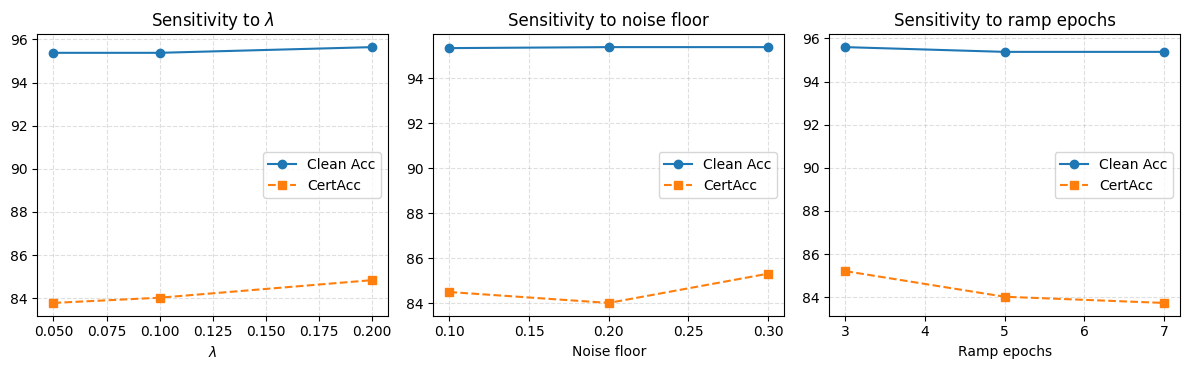

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("results_sensitivity_analysis/sensitivity_summary.csv")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))

# λ sensitivity
tmp = df[(df["noise_floor"] == 0.20) & (df["ramp_epochs"] == 5)].sort_values("lambda")
axes[0].plot(tmp["lambda"], tmp["clean_acc"], marker='o', label="Clean Acc")
axes[0].plot(tmp["lambda"], tmp["avg_cert_acc"], marker='s', linestyle='--', label="CertAcc")
axes[0].set_title(r"Sensitivity to $\lambda$")
axes[0].set_xlabel(r"$\lambda$")
axes[0].grid(True, linestyle="--", alpha=0.4)
axes[0].legend()

# noise floor sensitivity
tmp = df[(df["lambda"] == 0.10) & (df["ramp_epochs"] == 5)].sort_values("noise_floor")
axes[1].plot(tmp["noise_floor"], tmp["clean_acc"], marker='o', label="Clean Acc")
axes[1].plot(tmp["noise_floor"], tmp["avg_cert_acc"], marker='s', linestyle='--', label="CertAcc")
axes[1].set_title("Sensitivity to noise floor")
axes[1].set_xlabel("Noise floor")
axes[1].grid(True, linestyle="--", alpha=0.4)
axes[1].legend()

# ramp sensitivity
tmp = df[(df["lambda"] == 0.10) & (df["noise_floor"] == 0.20)].sort_values("ramp_epochs")
axes[2].plot(tmp["ramp_epochs"], tmp["clean_acc"], marker='o', label="Clean Acc")
axes[2].plot(tmp["ramp_epochs"], tmp["avg_cert_acc"], marker='s', linestyle='--', label="CertAcc")
axes[2].set_title("Sensitivity to ramp epochs")
axes[2].set_xlabel("Ramp epochs")
axes[2].grid(True, linestyle="--", alpha=0.4)
axes[2].legend()

plt.tight_layout()
plt.savefig("results_sensitivity_analysis/sensitivity_plot.pdf", dpi=300, bbox_inches="tight")
plt.show()